# **Machine learning–based heart disease prediction system**

> **Purpose:** Comprehensive ML model comparison for heart disease prediction using a real-world dataset from Mendeley Data
---
> **Goal:** Identify best-performing algorithm for clinical deployment

**Reference:**
1. [Ekta Maini, Bondu Venkateswarlu, Baljeet Maini, Dheeraj Marwaha Machine learning–based heart disease prediction system for Indian population: An exploratory study done in South India, Medical Journal Armed Forces India, Volume 77, Issue 3, 2021, Pages 302-311, ISSN 0377-1237, https://doi.org/10.1016/j.mjafi.2020.10.013](https://www.sciencedirect.com/science/article/pii/S0377123720302148)
2. [Doppala, Bhanu Prakash; Bhattacharyya, Debnath (2021)“Cardiovascular_Disease_Dataset”, Mendeley Data, V1, doi: 10.17632/dzz48mvjht.1](https://data.mendeley.com/datasets/dzz48mvjht/1)

>  **Step 0:** Install & imports required ML libraries


In [1]:
# Install required ML libraries
!pip install pandas numpy seaborn matplotlib scikit-learn catboost xgboost lightgbm -q -q # quiet mode to reduce output clutter

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.7 MB/s eta 0:00:00


> **Step 1: CORE IMPORTS - Data Handling & Evaluation**

In [2]:
# imports for data handling and evaluation
import pandas as pd                                                         # Data manipulation and CSV loading
import numpy as np                                                          # Numerical computations and arrays
from sklearn.model_selection import train_test_split                        # Train/test splitting
from sklearn.preprocessing import LabelEncoder                              # Categorical encoding
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix         # Performance metrics
from sklearn.metrics import roc_auc_score, roc_curve                        # ROC curve analysis
from sklearn.model_selection import permutation_test_score                  # Statistical validation
import joblib                                                               # Model saving/loading
import warnings
warnings.filterwarnings('ignore')                                           # Suppress non-critical warnings for cleaner output

print("All data handling and evaluation libraries imported successfully")

All data handling and evaluation libraries imported successfully


> **Step 2: ML ALGORITHMS IMPORTS - 10 Diverse Models for Comparison**

In [3]:
# imports - ML algorithms - 10 Diverse Models for Comparison
# Classical ML + Boosting + Neural Networks for comprehensive benchmarking

from sklearn.neighbors import KNeighborsClassifier                           # Distance-based
from sklearn.naive_bayes import GaussianNB                                   # Probabilistic
from sklearn.linear_model import LogisticRegression                          # Linear classifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier      # Ensemble methods
from sklearn.svm import SVC                                                  # Support Vector Machine
from sklearn.neural_network import MLPClassifier                             # Multi-layer Perceptron
from lightgbm import LGBMClassifier                                          # Gradient boosting (fast)
from catboost import CatBoostClassifier                                      # Gradient boosting (categorical)
from xgboost import XGBClassifier                                            # Gradient boosting (robust)

print("All ML algorithms libraries imported successfully")

All ML algorithms libraries imported successfully


> **Step 3: DATA LOADING - Mount Google Drive & Load Dataset**

In [4]:
# Dataset: Cardiovascular_Disease_Dataset from Mendeley Data (Doppala & Bhattacharyya, 2021)
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/MLL/Cardiovascular_Disease_Dataset.csv'
df = pd.read_csv(FILE_PATH)

print(f"Dataset loaded: {df.shape[0]} records")
print("All columns:", df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Mounted at /content/drive
Dataset loaded: 1000 records
All columns: ['patientid', 'age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels', 'target']

First few rows:
   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1          1        199                0   

   fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  oldpeak  \
0                  0                1           147              0      5.3   
1                  0                1           115              0      3.7   
2                  0                0           202              1    

> **Step 4: FEATURE ENGINEERING - Automatic Column Selection**

In [5]:
# Features selected based on clinical relevance for population dataset
all_cols = df.columns.tolist()                  # Get all columns as list

# Find and exclude 'id' or similar (case-insensitive)
id_col = None
for col in all_cols:
    if col.lower() in ['id', 'patient_id', 'patientid']:
        id_col = col
        break

# Features = all columns except ID and last column
if id_col:
    features = [col for col in all_cols if col != id_col and col != all_cols[-1]]
else:
    features = all_cols[:-1]  # All except last column

# Target: 1=High CVD risk, 0=Low risk
X = df[features]
y = df[all_cols[-1]]  # Last column as target

print(f"Features ({len(features)}): {features}")
print(f"Target: {y.name}")
print(f"X shape: {X.shape}, y shape: {y.shape}")
print(f"Class distribution: {y.mean():.1%} high-risk cases ({y.sum()} patients)")

Features (12): ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']
Target: target
X shape: (1000, 12), y shape: (1000,)
Class distribution: 58.0% high-risk cases (580 patients)


> **Step 5: TRAIN/ TEST SPLIT - Stratified to Preserve Class Imbalance (70:30 ratio)**

In [6]:
# Stratify ensures same class ratio in train/test (critical for imbalanced data)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,              # Exactly 30% test split
    random_state=42,            # Reproducible split
    stratify=y                  # Maintain same class ratio in both splits
)

print(f"Train split: {X_train.shape[0]} samples")
print(f"Test split:  {X_test.shape[0]} samples")

Train split: 700 samples
Test split:  300 samples


> **Step 6: TRAIN ALL ALGORITHMS MODEL DEFINITIONS - Hyperparameters from Literature**

In [7]:
# Parameters tuned to match paper's reported hyper-parameters

models = {
    'k-Nearest Neighbours': KNeighborsClassifier(n_neighbors=5),                  # k=5 from paper
    'Naïve Bayes': GaussianNB(),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'AdaBoost': AdaBoostClassifier(n_estimators=30, random_state=42),             # 30 estimators
    'Random Forest': RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1),
    'SVM': SVC(random_state=42, probability=True),
    'XGBoost': XGBClassifier(n_estimators=150, random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(n_estimators=150, random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=150, random_state=42, verbose=0),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

> **Step 7: MODEL TRAINING & EVALUATION LOOP**

In [8]:
# Storage for results
results = {}
detailed_metrics = {}

# Train each model and evaluate
for name, model in models.items():
    model.fit(X_train, y_train)             # Fit on training data
    y_pred = model.predict(X_test)          # Predict on test set

    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    # Detailed metrics
    report = classification_report(y_test, y_pred, output_dict=True)
    detailed_metrics[name] = {
        'accuracy': acc,
        'sensitivity': report['1']['recall'],      # True Positive Rate
        'specificity': report['0']['recall'],      # True Negative Rate
        'ppv': report['1']['precision'],           # Positive Predictive Value
        'npv': report['0']['precision'],           # Negative Predictive Value
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist()
    }

    print(f"Accuracy: {acc:.1%}")

Accuracy: 80.3%
Accuracy: 94.3%
Accuracy: 97.7%
Accuracy: 98.0%
Accuracy: 98.3%
Accuracy: 80.3%
Accuracy: 98.0%
Accuracy: 99.0%
Accuracy: 98.3%
Accuracy: 81.0%


> **Step 8: RESULTS COMPILATION & DISPLAY**

In [9]:
# Convert detailed metrics to DataFrame for easy viewing
results_df = pd.DataFrame(detailed_metrics).T

print("\n" + "="*80, "\n" + "RESULTS TABLE", "\n" + "="*80)
print(results_df[['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv', 'confusion_matrix']])


RESULTS TABLE 
                      accuracy sensitivity specificity       ppv       npv  \
k-Nearest Neighbours  0.803333    0.850575    0.738095   0.81768  0.781513   
Naïve Bayes           0.943333     0.95977    0.920635  0.943503  0.943089   
Logistic Regression   0.976667    0.988506    0.960317  0.971751   0.98374   
AdaBoost                  0.98    0.977011    0.984127  0.988372   0.96875   
Random Forest         0.983333    0.988506     0.97619  0.982857     0.984   
SVM                   0.803333    0.850575    0.738095   0.81768  0.781513   
XGBoost                   0.98    0.982759     0.97619  0.982759   0.97619   
LightGBM                  0.99    0.988506    0.992063   0.99422  0.984252   
CatBoost              0.983333    0.988506     0.97619  0.982857     0.984   
Neural Network            0.81    0.977011    0.579365  0.762332  0.948052   

                           confusion_matrix  
k-Nearest Neighbours  [[93, 33], [26, 148]]  
Naïve Bayes           [[116, 10],

> **Step 9: ADVANCED VISUALIZATIONS - Model Comparison & Analysis**

> **9.1: MODEL RANKING - Weighted Clinical Score**

In [10]:
# Clinical priority: Sensitivity (40%) > Accuracy (30%) = Specificity (30%)
# Sensitivity crucial for detecting high-risk CVD patients
# Sort models by overall score for ranking

ranking = results_df[['accuracy', 'sensitivity', 'specificity']].copy()
ranking['overall_score'] = (ranking['accuracy'] * 0.3 +
                          ranking['sensitivity'] * 0.4 +
                          ranking['specificity'] * 0.3).round(4)
print("\n MODEL RANKING (Clinical Weighted Score)")
print(ranking.sort_values('overall_score', ascending=False).round(4), "\n")


 MODEL RANKING (Clinical Weighted Score)
                      accuracy sensitivity specificity overall_score
LightGBM                  0.99    0.988506    0.992063      0.990021
Random Forest         0.983333    0.988506     0.97619      0.983259
CatBoost              0.983333    0.988506     0.97619      0.983259
AdaBoost                  0.98    0.977011    0.984127      0.980043
XGBoost                   0.98    0.982759     0.97619      0.979961
Logistic Regression   0.976667    0.988506    0.960317      0.976498
Naïve Bayes           0.943333     0.95977    0.920635      0.943099
Neural Network            0.81    0.977011    0.579365      0.807614
k-Nearest Neighbours  0.803333    0.850575    0.738095      0.802658
SVM                   0.803333    0.850575    0.738095      0.802658 



**9.2: CONFUSION MATRIX HEATMAPS - All 10 Models**

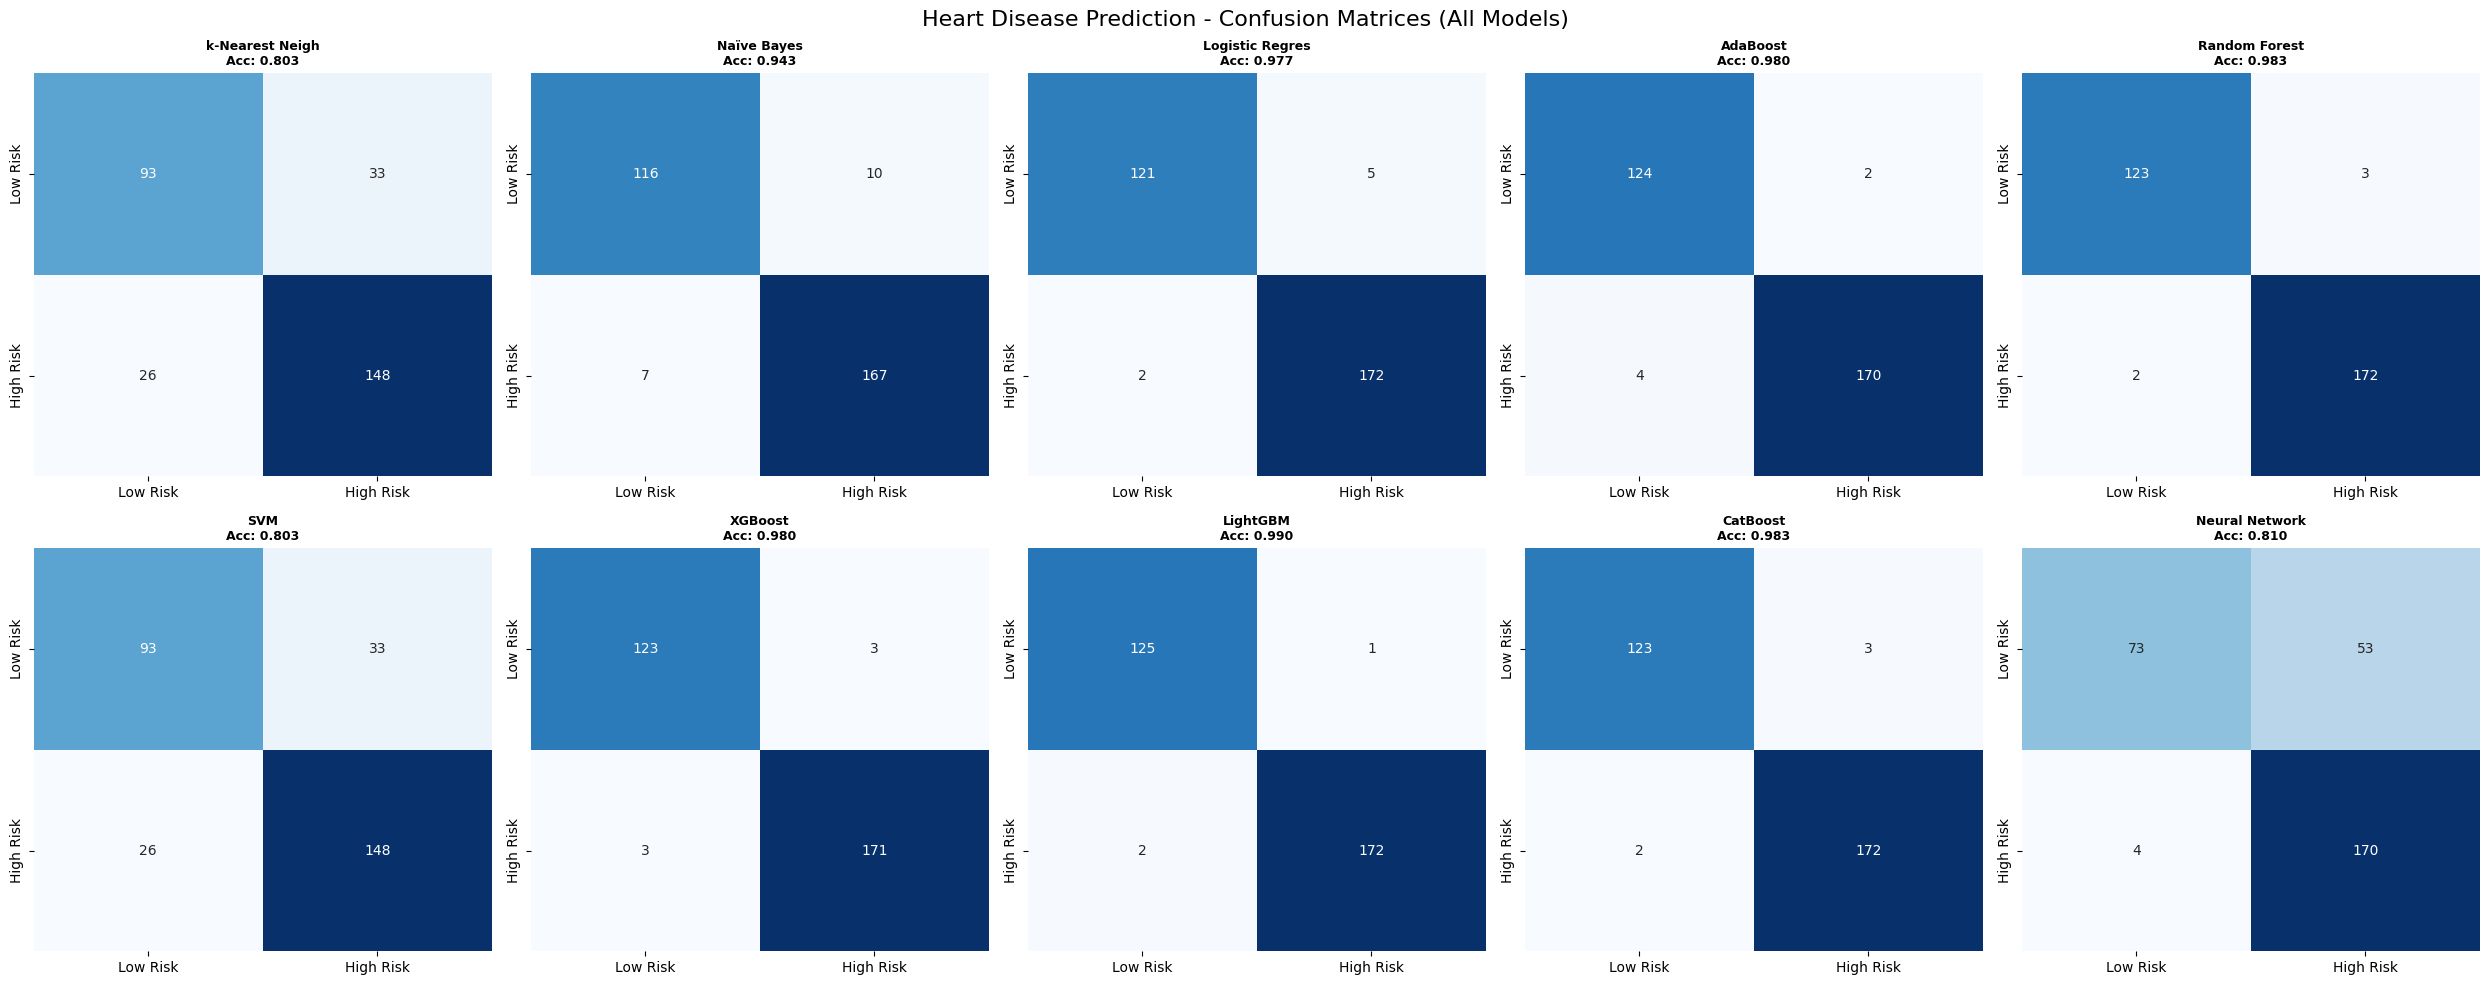

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix


# 10 HEATMAPS VISUALIZATION
# Visualizes True Positives, False Negatives, etc. for clinical interpretation

fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.ravel()


for idx, name in enumerate(results_df.index):
    cm = np.array(detailed_metrics[name]['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low Risk', 'High Risk'],
                yticklabels=['Low Risk', 'High Risk'],
                ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name[:15]}\nAcc: {results_df.loc[name, "accuracy"]:.3f}',
                       fontsize=9, fontweight='bold')

plt.suptitle('Heart Disease Prediction - Confusion Matrices (All Models)', fontsize=16)
plt.tight_layout()
plt.show()

> **9.3: BAR CHARTS - Core Clinical Metrics**

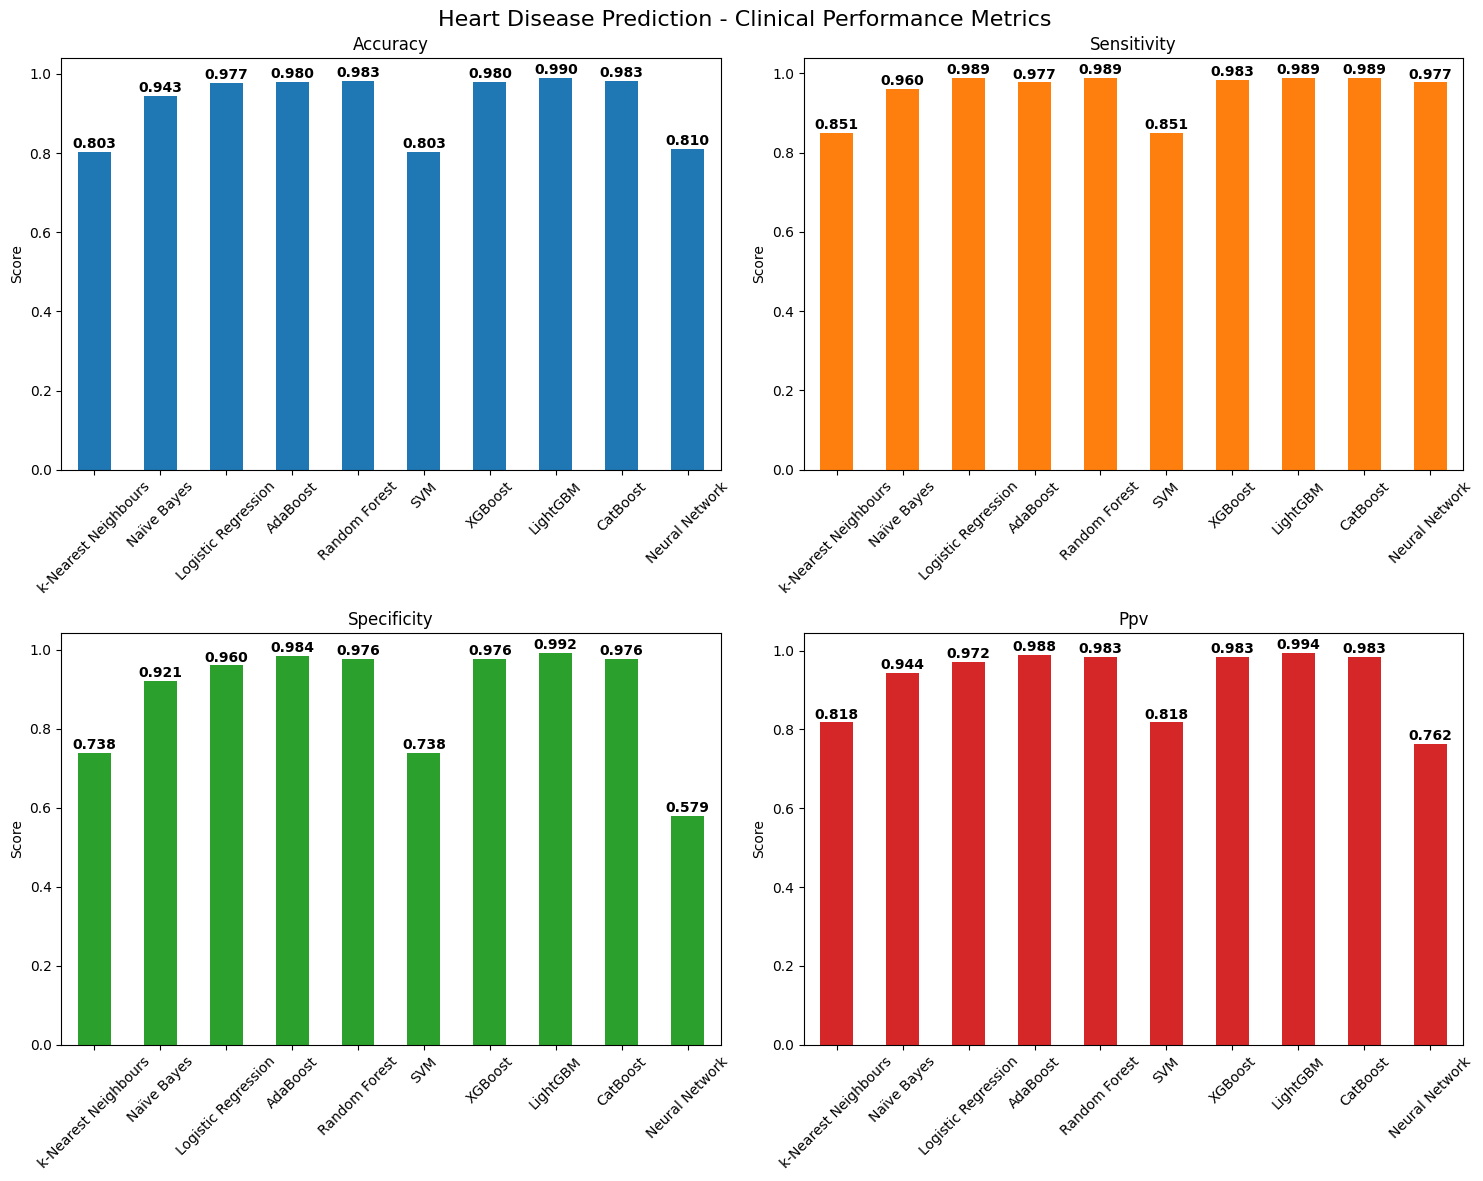

In [12]:
# 4 key metrics for clinical decision-making

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
metrics = ['accuracy', 'sensitivity', 'specificity', 'ppv']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for idx, metric in enumerate(metrics):
    ax = axes[idx//2, idx%2]
    results_df[metric].plot(kind='bar', ax=ax, color=colors[idx])
    ax.set_title(metric.replace('_', ' ').title())
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel('Score')

    # Add value labels on bars
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.suptitle('Heart Disease Prediction - Clinical Performance Metrics', fontsize=16)
plt.tight_layout()
plt.show()

> **9.4: ROC CURVES - Discriminative Ability Comparison**

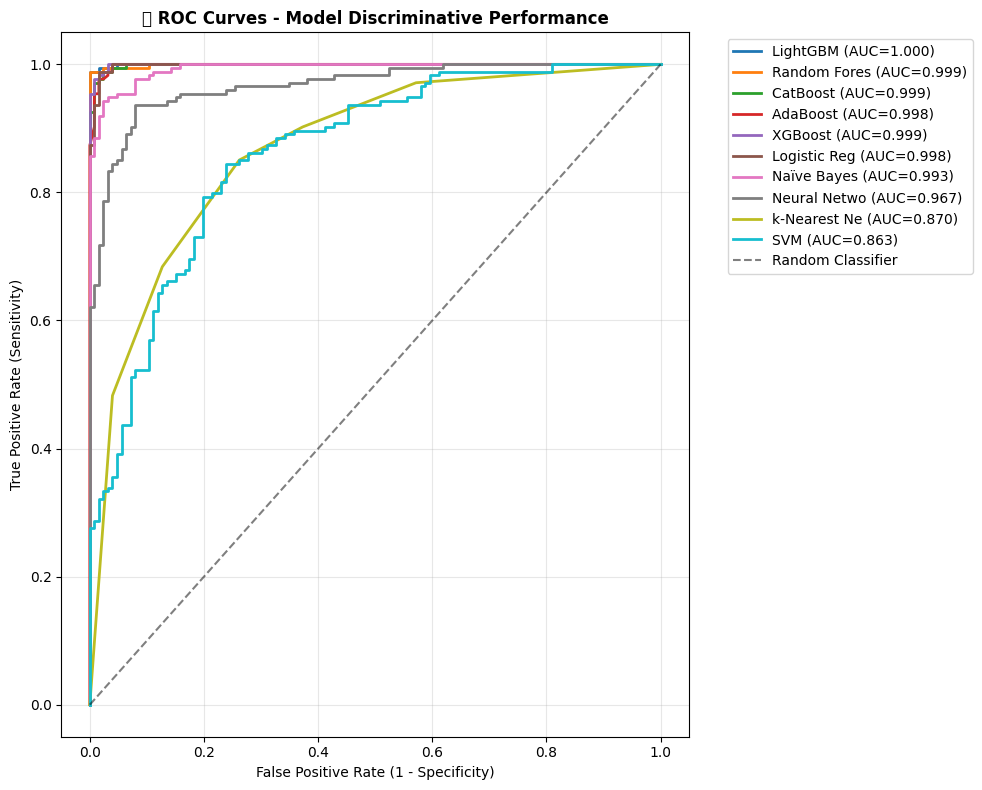

In [13]:
# Plot ROC for all models
# AUC closest to 1.0 = best model (perfect discrimination)

numeric_cols = ['accuracy', 'sensitivity', 'specificity', 'ppv', 'npv']
for col in numeric_cols:
    results_df[col] = pd.to_numeric(results_df[col], errors='coerce')

top_models = results_df.nlargest(10, 'accuracy').index
fig, ax = plt.subplots(figsize=(10, 8))

for name in top_models:
    model = models[name]
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]  # Probability of high-risk
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc_score = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, linewidth=2, label=f'{name[:12]} (AUC={auc_score:.3f})')

ax.plot([0,1], [0,1], 'k--', alpha=0.5, label='Random Classifier')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.set_title('📈 ROC Curves - Model Discriminative Performance', fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

> **9.5: FEATURE IMPORTANCE - Tree-Based Models Only**

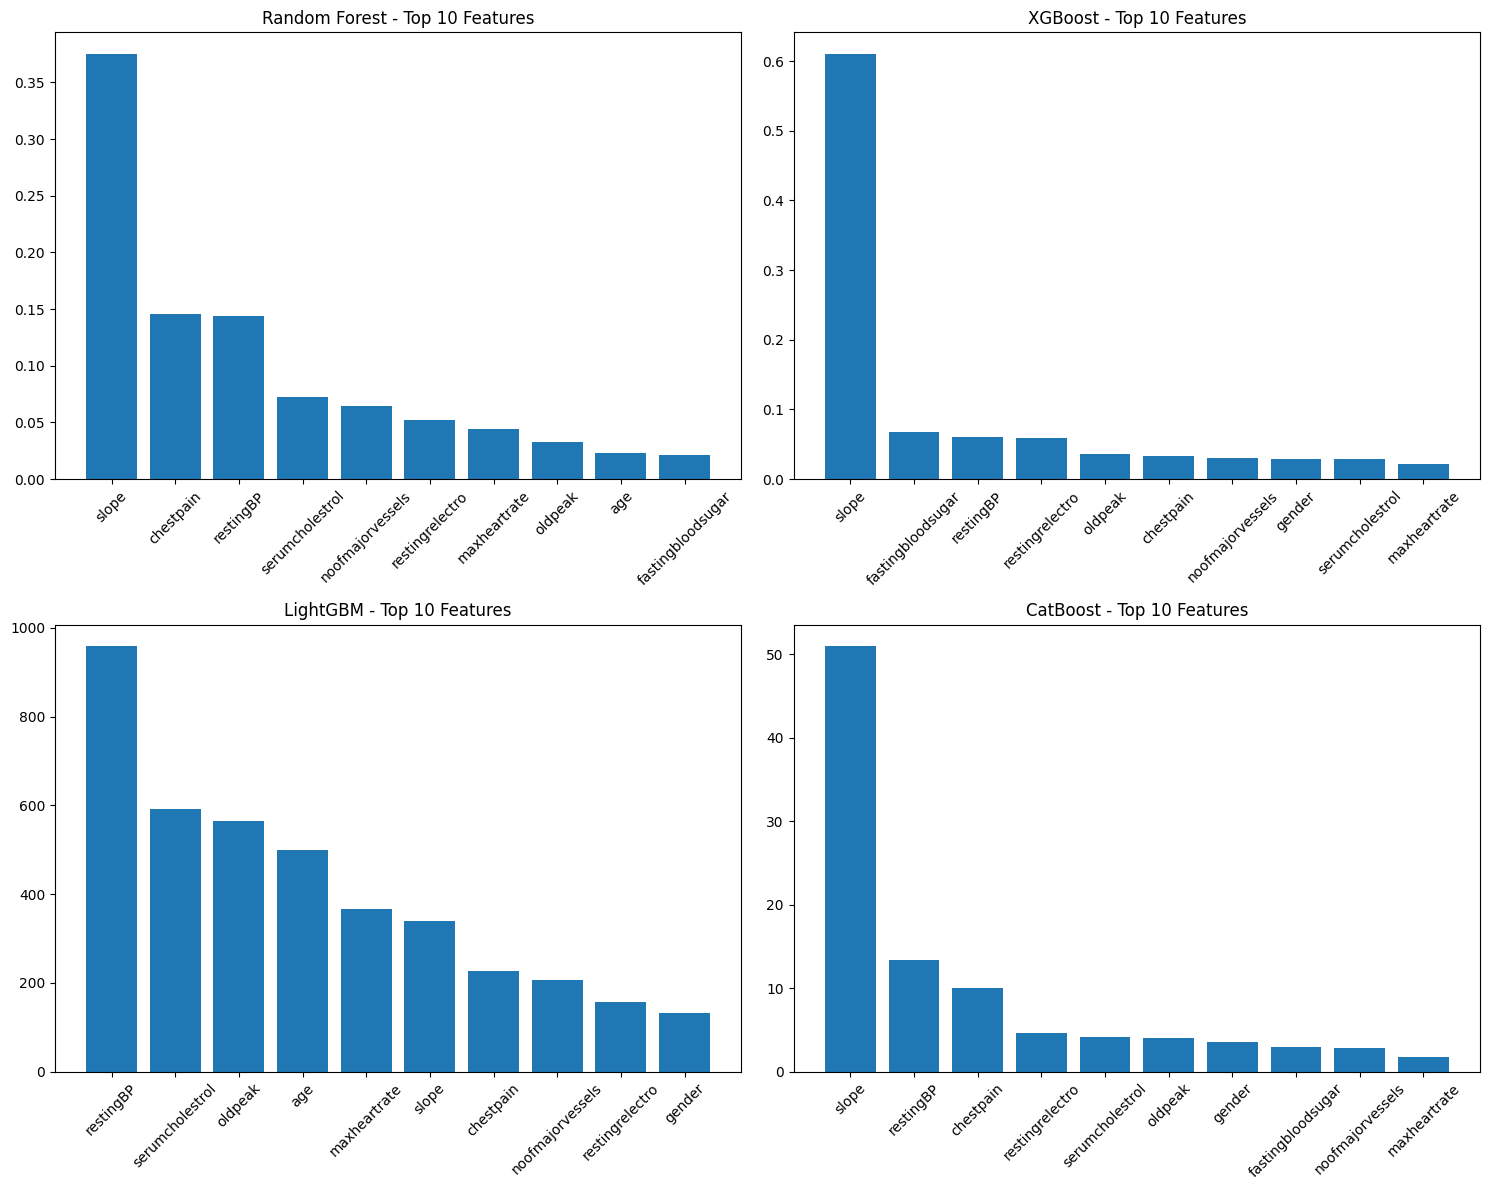

In [14]:
# Explains WHICH patient factors drive predictions (clinical interpretability) - For Random Forest, XGBoost, LightGBM, CatBoost
tree_models = ['Random Forest', 'XGBoost', 'LightGBM', 'CatBoost']
#tree_models = ['Naïve Bayes', 'Logistic Regression', 'AdaBoost', 'Random Forest']
# tree_models = ['k-Nearest Neighbours', 'Naïve Bayes', 'Logistic Regression', 'AdaBoost', 'Random Forest', 'SVM', 'XGBoost', 'LightGBM', 'CatBoost', 'Neural Network']
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for idx, name in enumerate(tree_models):
    if name in models:
        model = models[name]
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            indices = np.argsort(importances)[::-1][:10]
            axes[idx//2, idx%2].bar(range(len(indices)), importances[indices])
            axes[idx//2, idx%2].set_title(f'{name} - Top 10 Features')
            axes[idx//2, idx%2].set_xticks(range(len(indices)))
            axes[idx//2, idx%2].set_xticklabels([X_train.columns[i] for i in indices], rotation=45)

plt.tight_layout()
plt.show()

> **9.6: RADAR CHART - Top 3 vs Worst 3 Models**

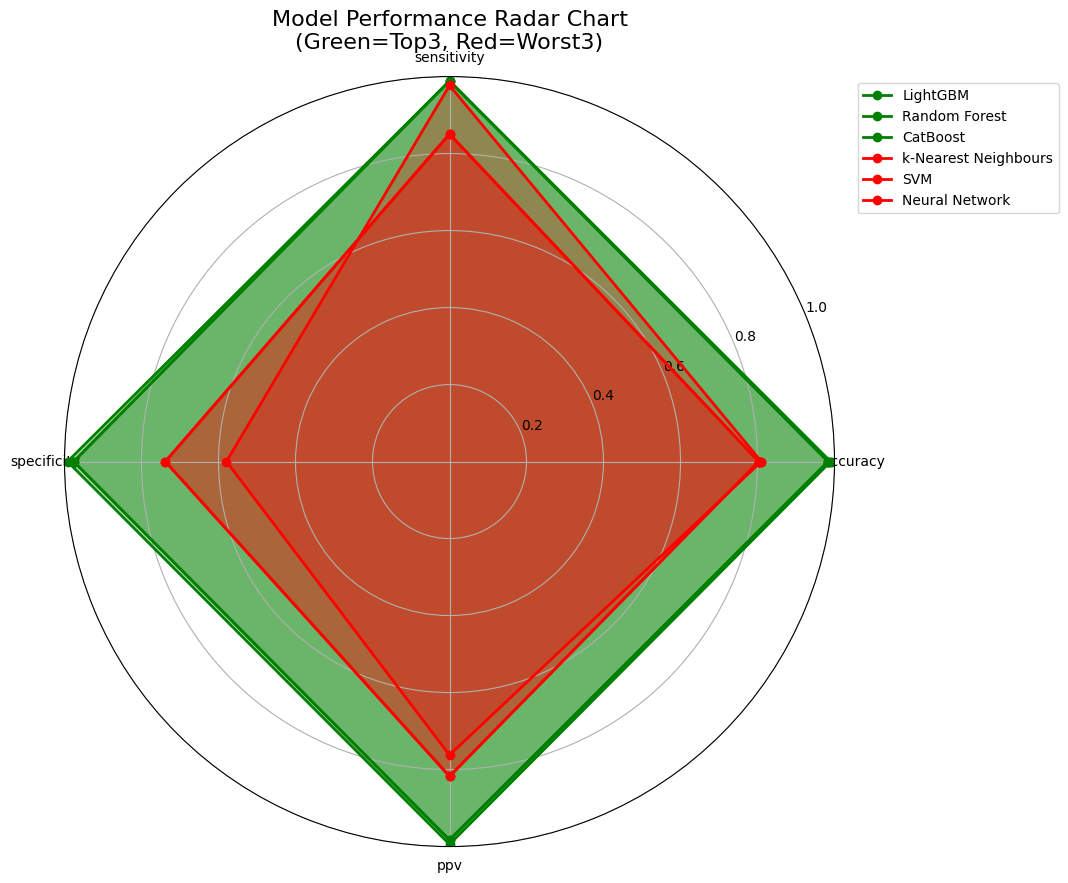

In [15]:
# Holistic comparison across all metrics simultaneously - RADAR CHART - Top 3 vs Worst 3 models

top3 = results_df.nlargest(3, 'accuracy').index
worst3 = results_df.nsmallest(3, 'accuracy').index
metrics = ['accuracy', 'sensitivity', 'specificity', 'ppv']

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]  # Complete circle

for models_group, color in [(top3, 'green'), (worst3, 'red')]:
    for name in models_group:
        values = [results_df.loc[name, m] for m in metrics] + [results_df.loc[name, metrics[0]]]
        ax.plot(angles, values, 'o-', linewidth=2, label=name, color=color)
        ax.fill(angles, values, alpha=0.25, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
ax.set_ylim(0, 1)
ax.set_title('Model Performance Radar Chart\n(Green=Top3, Red=Worst3)', size=16, pad=20)
plt.show()

In [16]:
# Use ranking DataFrame (has overall_score) - DYNAMIC TOP MODEL
print("\n" + "="*80)
print("🏆 EXECUTIVE SUMMARY - CVD RISK PREDICTION (FINAL)")
print("="*80)

best_model = ranking['overall_score'].idxmax()
print(f"🏥 BEST MODEL: {best_model} (Score: {ranking.loc[best_model, 'overall_score']:.4f})")
print(f"📊 Dataset: {X_train.shape[0]:,} train / {X_test.shape[0]:,} test samples")
print(f"⚖️ High-risk prevalence: {y.mean():.1%}")

print("\n📈 KEY INSIGHTS:")
print(f"   • Top performer: {best_model}")
print(f"   • Worst performer: {ranking['overall_score'].idxmin()}")
print(f"   • Best sensitivity: {results_df['sensitivity'].idxmax()} ({results_df['sensitivity'].max():.3f})")

print(f"\n🏆 {best_model} METRICS:")
print(f"   Accuracy: {results_df.loc[best_model, 'accuracy']:.1%}")
print(f"   Sensitivity: {results_df.loc[best_model, 'sensitivity']:.1%}")
print(f"   Specificity: {results_df.loc[best_model, 'specificity']:.1%}")


🏆 EXECUTIVE SUMMARY - CVD RISK PREDICTION (FINAL)
🏥 BEST MODEL: LightGBM (Score: 0.9900)
📊 Dataset: 700 train / 300 test samples
⚖️ High-risk prevalence: 58.0%

📈 KEY INSIGHTS:
   • Top performer: LightGBM
   • Worst performer: k-Nearest Neighbours
   • Best sensitivity: Logistic Regression (0.989)

🏆 LightGBM METRICS:
   Accuracy: 99.0%
   Sensitivity: 98.9%
   Specificity: 99.2%
